## Preliminary Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set up plot styling
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (20, 6)

In [2]:
# Load the data
customers = pd.read_csv('Wholesale_customers_data.csv')

In [3]:
# View the first few rows
customers.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [4]:
# Check dimensions and structure
print(f"Dimensions: {customers.shape}")
customers.info()

Dimensions: (440, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicatessen      440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [8]:
customers.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [9]:
# Convert Channel and Region to categorical variables
customers['Channel'] = customers['Channel'].astype('category')
customers['Region'] = customers['Region'].astype('category')

In [10]:
# Check structure again after conversion
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   Channel           440 non-null    category
 1   Region            440 non-null    category
 2   Fresh             440 non-null    int64   
 3   Milk              440 non-null    int64   
 4   Grocery           440 non-null    int64   
 5   Frozen            440 non-null    int64   
 6   Detergents_Paper  440 non-null    int64   
 7   Delicatessen      440 non-null    int64   
dtypes: category(2), int64(6)
memory usage: 21.9 KB


In [11]:
# Summary statistics
customers.describe()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicatessen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [12]:
# Crosstab of Channel vs Region (equivalent to table in R)
pd.crosstab(customers['Channel'], customers['Region'])

Region,1,2,3
Channel,,,
1,59,28,211
2,18,19,105


In [14]:
customers[['Channel', 'Region']].value_counts()


Channel  Region
1        3         211
2        3         105
1        1          59
         2          28
2        2          19
         1          18
Name: count, dtype: int64

In [17]:
# Select only numeric features
customer_features = customers.select_dtypes(include=int)
customer_features.shape

(440, 6)

In [18]:
# Create summary dataframe
sum_vals = pd.DataFrame({'feature': customer_features.columns})
sum_vals['mean_'] = customer_features.mean().values
sum_vals['median_'] = customer_features.median().values
sum_vals['sd_'] = customer_features.std().values
sum_vals

,feature,mean_,median_,sd_
0,Fresh,12000.297727,8504.0,12647.328865
1,Milk,5796.265909,3627.0,7380.377175
2,Grocery,7951.277273,4755.5,9503.162829
3,Frozen,3071.931818,1526.0,4854.673333
4,Detergents_Paper,2881.493182,816.5,4767.854448
5,Delicatessen,1524.870455,965.5,2820.105937


In [19]:
# Melt the dataframe for plotting (similar to reshape2::melt in R)
melted_sum = pd.melt(sum_vals, id_vars=['feature'], var_name='statistic', value_name='value')
melted_sum

,feature,statistic,value
0,Fresh,mean_,12000.297727
1,Milk,mean_,5796.265909
2,Grocery,mean_,7951.277273
3,Frozen,mean_,3071.931818
4,Detergents_Paper,mean_,2881.493182
5,Delicatessen,mean_,1524.870455
6,Fresh,median_,8504.000000
7,Milk,median_,3627.000000
8,Grocery,median_,4755.500000
9,Frozen,median_,1526.000000


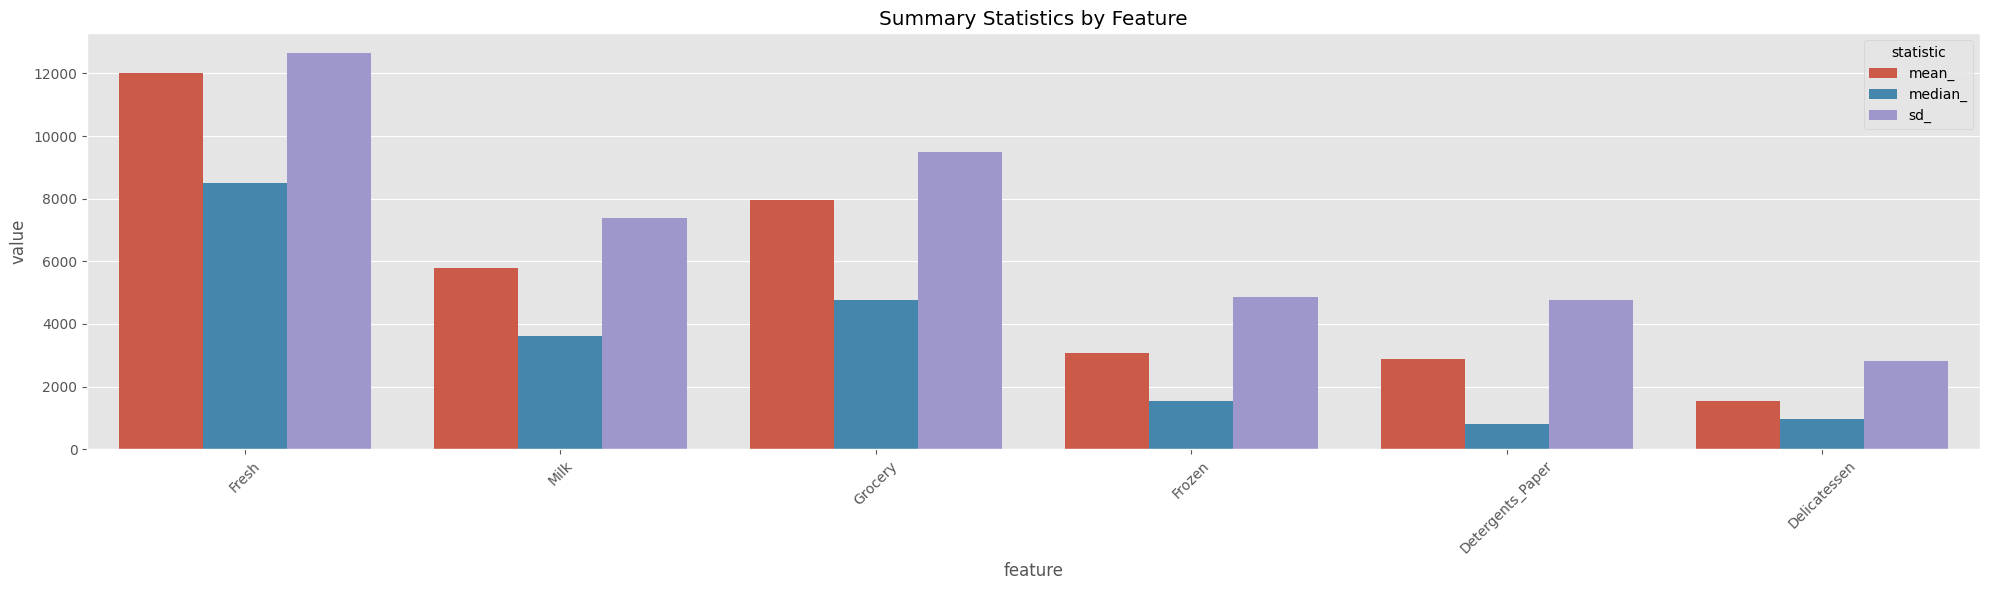

In [20]:
# Create bar plot similar to ggplot2
plt.figure(figsize=(20, 6))
g = sns.barplot(x='feature', y='value', hue='statistic', data=melted_sum)
plt.title('Summary Statistics by Feature')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
# measure the skew of the features
customer_features.skew()

Fresh                2.561323
Milk                 4.053755
Grocery              3.587429
Frozen               5.907986
Detergents_Paper     3.631851
Delicatessen        11.151586
dtype: float64

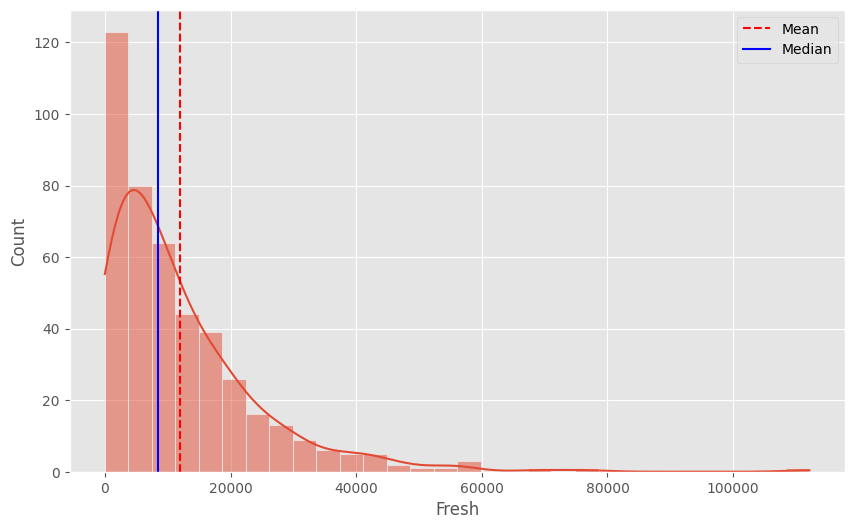

In [22]:
# plot the distribution of the fresh feature with mean and median
plt.figure(figsize=(10, 6))
sns.histplot(customer_features['Fresh'], bins=30, kde=True)
plt.axvline(customer_features['Fresh'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(customer_features['Fresh'].median(), color='blue', linestyle='-', label='Median')
plt.legend()
plt.show()
